In [2]:
!pip install -q opencv-python pillow numpy matplotlib tqdm

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path

DATASET = Path("/content/drive/MyDrive/wall_floor_seg")

IMG_DIR = DATASET / "dataset/data"
COCO_JSON = DATASET / "dataset/_annotations.coco.json"

TRAIN_DIR = DATASET / "dataset/train"
VAL_DIR = DATASET / "dataset/val"
TEST_DIR = DATASET / "dataset/test"

for d in [
    TRAIN_DIR / "images",
    VAL_DIR / "images",
    TEST_DIR / "images"
]:
    d.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET)

Dataset: /content/drive/MyDrive/wall_floor_seg


In [5]:
import json

with open(COCO_JSON, "r") as f:
    coco = json.load(f)

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))
print("Categories:", coco["categories"])

Images: 783
Annotations: 5589
Categories: [{'id': 0, 'name': 'wall-ceiling-floor', 'supercategory': 'none'}, {'id': 1, 'name': 'floor', 'supercategory': 'wall-ceiling-floor'}, {'id': 2, 'name': 'wall', 'supercategory': 'wall-ceiling-floor'}]


In [6]:
import random

random.seed(42)

images = coco["images"].copy()
random.shuffle(images)

n = len(images)

n_train = int(0.80 * n)
n_val = int(0.10 * n)

train_images = images[:n_train]
val_images = images[n_train:n_train+n_val]
test_images = images[n_train+n_val:]

print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))

Train: 626
Val: 78
Test: 79


In [7]:
import shutil

def create_split(split_images, split_dir):

    image_ids = {img["id"] for img in split_images}

    split_annotations = [
        ann for ann in coco["annotations"]
        if ann["image_id"] in image_ids
    ]

    split_coco = {
        "info": coco.get("info", {}),
        "licenses": coco.get("licenses", []),
        "categories": coco["categories"],
        "images": split_images,
        "annotations": split_annotations
    }

    for img in split_images:
        src = IMG_DIR / Path(img["file_name"]).name
        dst = split_dir / "images" / src.name

        if src.exists():
            shutil.copy2(src, dst)
        else:
            print("Missing:", src)

    with open(
        split_dir / "_annotations.coco.json",
        "w"
    ) as f:
        json.dump(split_coco, f)

    print(
        split_dir.name,
        "-> images:",
        len(split_images),
        "annotations:",
        len(split_annotations)
    )

In [8]:
create_split(train_images, TRAIN_DIR)
create_split(val_images, VAL_DIR)
create_split(test_images, TEST_DIR)

train -> images: 626 annotations: 4473
val -> images: 78 annotations: 531
test -> images: 79 annotations: 585


In [9]:
import os
import json
import random
import numpy as np
import cv2
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
NUM_CLASSES = 3
IMG_W, IMG_H = 512, 288
BATCH_SIZE = 16
EPOCHS = 100
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 12

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

Device: cuda
GPU: Tesla T4


In [26]:
ROOT = Path("/content/drive/MyDrive/wall_floor_seg/dataset")

TRAIN_IMG = ROOT / "train/images"
TRAIN_JSON = ROOT / "train/_annotations.coco.json"

VAL_IMG = ROOT / "val/images"
VAL_JSON = ROOT / "val/_annotations.coco.json"

TEST_IMG = ROOT / "test/images"
TEST_JSON = ROOT / "test/_annotations.coco.json"

MASK_ROOT = ROOT / "masks"

for p in [MASK_ROOT/"train", MASK_ROOT/"valid", MASK_ROOT/"test"]:
    p.mkdir(parents=True, exist_ok=True)

print(TRAIN_IMG)

/content/drive/MyDrive/wall_floor_seg/dataset/train/images


In [28]:
def show_categories(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    for cat in data["categories"]:
        print(cat["id"], "->", cat["name"])

show_categories(TRAIN_JSON)

0 -> wall-ceiling-floor
1 -> floor
2 -> wall


In [29]:
from pycocotools.coco import COCO

def coco_to_masks(json_path, image_dir, output_dir):
    coco = COCO(str(json_path))

    categories = coco.loadCats(coco.getCatIds())
    cat_map = {c["name"].lower(): c["id"] for c in categories}

    print("Categories:", cat_map)

    wall_id = cat_map.get("wall")
    floor_id = cat_map.get("floor")

    if wall_id is None or floor_id is None:
        raise ValueError(
            f"wall/floor not found. Categories: {cat_map}"
        )

    image_ids = coco.getImgIds()

    for image_id in tqdm(image_ids):
        img_info = coco.loadImgs(image_id)[0]

        h = img_info["height"]
        w = img_info["width"]

        mask = np.zeros((h, w), dtype=np.uint8)

        ann_ids = coco.getAnnIds(
            imgIds=[image_id],
            catIds=[wall_id, floor_id],
            iscrowd=None
        )

        anns = coco.loadAnns(ann_ids)

        for ann in anns:
            cat_id = ann["category_id"]

            if cat_id == wall_id:
                class_id = 1
            elif cat_id == floor_id:
                class_id = 2
            else:
                continue

            polygons = ann.get("segmentation", [])

            if isinstance(polygons, list):
                for polygon in polygons:
                    if len(polygon) >= 6:
                        pts = np.array(
                            polygon,
                            dtype=np.float32
                        ).reshape(-1, 2)

                        pts = np.round(pts).astype(np.int32)

                        cv2.fillPoly(
                            mask,
                            [pts],
                            class_id
                        )

        output_path = output_dir / (
            Path(img_info["file_name"]).stem + ".png"
        )

        cv2.imwrite(
            str(output_path),
            mask
        )

    print("Masks saved:", output_dir)

In [34]:
coco_to_masks(
    TRAIN_JSON,
    TRAIN_IMG,
    MASK_ROOT / "train"
)

coco_to_masks(
    VAL_JSON,
    VAL_IMG,
    MASK_ROOT / "valid"
)

coco_to_masks(
    TEST_JSON,
    TEST_IMG,
    MASK_ROOT / "test"
)

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!
Categories: {'wall-ceiling-floor': 0, 'floor': 1, 'wall': 2}


  0%|          | 0/626 [00:00<?, ?it/s]

Masks saved: /content/drive/MyDrive/wall_floor_seg/dataset/masks/train
loading annotations into memory...
Done (t=10.04s)
creating index...
index created!
Categories: {'wall-ceiling-floor': 0, 'floor': 1, 'wall': 2}


  0%|          | 0/78 [00:00<?, ?it/s]

Masks saved: /content/drive/MyDrive/wall_floor_seg/dataset/masks/valid
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Categories: {'wall-ceiling-floor': 0, 'floor': 1, 'wall': 2}


  0%|          | 0/79 [00:00<?, ?it/s]

Masks saved: /content/drive/MyDrive/wall_floor_seg/dataset/masks/test


Unique values: [0 1 2]


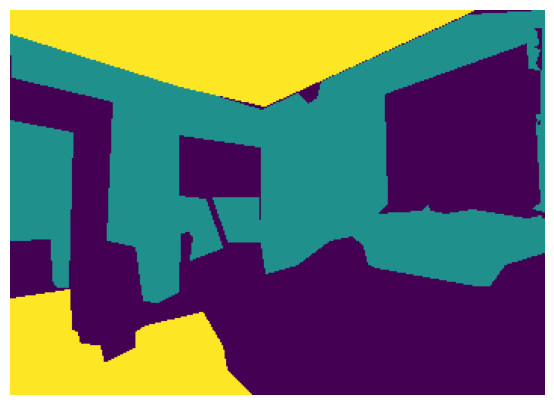

In [35]:
import matplotlib.pyplot as plt

mask_files = list((MASK_ROOT/"train").glob("*.png"))

mask = cv2.imread(
    str(mask_files[0]),
    cv2.IMREAD_GRAYSCALE
)

print("Unique values:", np.unique(mask))

plt.figure(figsize=(10,5))
plt.imshow(mask)
plt.axis("off")
plt.show()

In [36]:
class WallFloorDataset(Dataset):
    def __init__(self, image_dir, mask_dir, train=False):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.train = train

        self.images = []

        for ext in ["*.jpg", "*.jpeg", "*.png"]:
            self.images.extend(self.image_dir.glob(ext))

        self.images = sorted(self.images)

        self.images = [
            p for p in self.images
            if (self.mask_dir / f"{p.stem}.png").exists()
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        mask_path = self.mask_dir / f"{image_path.stem}.png"

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.resize(
            image,
            (IMG_W, IMG_H),
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            (IMG_W, IMG_H),
            interpolation=cv2.INTER_NEAREST
        )

        if self.train and random.random() < 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        if self.train and random.random() < 0.3:
            alpha = random.uniform(0.8, 1.2)
            beta = random.randint(-20, 20)

            image = cv2.convertScaleAbs(
                image,
                alpha=alpha,
                beta=beta
            )

        image = torch.from_numpy(image).permute(2,0,1).float() / 255.0
        mask = torch.from_numpy(mask).long()

        mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(3,1,1)

        std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(3,1,1)

        image = (image - mean) / std

        return image, mask

In [37]:
train_ds = WallFloorDataset(
    TRAIN_IMG,
    MASK_ROOT/"train",
    train=True
)

val_ds = WallFloorDataset(
    VAL_IMG,
    MASK_ROOT/"valid",
    train=False
)

test_ds = WallFloorDataset(
    TEST_IMG,
    MASK_ROOT/"test",
    train=False
)

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Train: 626
Val: 78
Test: 79


In [38]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_ch,
            in_ch // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            in_ch // 2 + skip_ch,
            out_ch
        )

    def forward(self, x, skip):
        x = self.up(x)

        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)

        x = F.pad(
            x,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2
            ]
        )

        x = torch.cat([skip, x], dim=1)

        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.e1 = DoubleConv(3, 64)
        self.e2 = Down(64, 128)
        self.e3 = Down(128, 256)
        self.e4 = Down(256, 512)
        self.b = Down(512, 1024)

        self.d1 = Up(1024, 512, 512)
        self.d2 = Up(512, 256, 256)
        self.d3 = Up(256, 128, 128)
        self.d4 = Up(128, 64, 64)

        self.out = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        b = self.b(e4)

        x = self.d1(b, e4)
        x = self.d2(x, e3)
        x = self.d3(x, e2)
        x = self.d4(x, e1)

        return self.out(x)

In [39]:
class DiceLoss(nn.Module):
    def __init__(self, num_classes=3, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)

        loss = 0

        for c in range(self.num_classes):
            pred = probs[:, c]
            true = (target == c).float()

            intersection = (pred * true).sum((1,2))

            dice = (
                2 * intersection + self.smooth
            ) / (
                pred.sum((1,2)) +
                true.sum((1,2)) +
                self.smooth
            )

            loss += (1 - dice).mean()

        return loss / self.num_classes


class BoundaryLoss(nn.Module):
    def __init__(self):
        super().__init__()

        sx = torch.tensor(
            [[-1,0,1],[-2,0,2],[-1,0,1]],
            dtype=torch.float32
        ).view(1,1,3,3)

        sy = torch.tensor(
            [[-1,-2,-1],[0,0,0],[1,2,1]],
            dtype=torch.float32
        ).view(1,1,3,3)

        self.register_buffer("sx", sx)
        self.register_buffer("sy", sy)

    def edge(self, x):
        gx = F.conv2d(x, self.sx, padding=1)
        gy = F.conv2d(x, self.sy, padding=1)

        return torch.sqrt(
            gx**2 + gy**2 + 1e-6
        )

    def forward(self, logits, target):
        probs = torch.softmax(logits, dim=1)

        loss = 0

        for c in [1, 2]:
            pred = probs[:, c:c+1]
            true = (target == c).float().unsqueeze(1)

            loss += F.l1_loss(
                self.edge(pred),
                self.edge(true)
            )

        return loss / 2

In [40]:
model = UNet(NUM_CLASSES).to(DEVICE)

ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss(NUM_CLASSES).to(DEVICE)
boundary_loss = BoundaryLoss().to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print(
    "Parameters:",
    sum(p.numel() for p in model.parameters())
)

Parameters: 31037763


In [41]:
def get_cm(pred, target):
    pred = pred.flatten()
    target = target.flatten()

    cm = torch.bincount(
        target * NUM_CLASSES + pred,
        minlength=NUM_CLASSES**2
    )

    return cm.reshape(NUM_CLASSES, NUM_CLASSES)


def get_metrics(cm):
    cm = cm.float()

    tp = torch.diag(cm)

    union = (
        cm.sum(0) +
        cm.sum(1) -
        tp
    )

    iou = tp / (union + 1e-7)

    dice = (
        2 * tp /
        (
            cm.sum(0) +
            cm.sum(1) +
            1e-7
        )
    )

    return iou.cpu().numpy(), dice.cpu().numpy()

In [42]:
def run_epoch(loader, training=True):

    model.train(training)

    total_loss = 0

    cm = torch.zeros(
        NUM_CLASSES,
        NUM_CLASSES,
        dtype=torch.int64
    )

    for images, masks in tqdm(loader, leave=False):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            logits = model(images)

            ce = ce_loss(logits, masks)
            dice = dice_loss(logits, masks)
            boundary = boundary_loss(
                logits,
                masks
            )

            loss = (
                0.50 * ce +
                0.40 * dice +
                0.10 * boundary
            )

        if training:
            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(optimizer)
            scaler.update()

        total_loss += (
            loss.item() * images.size(0)
        )

        preds = logits.argmax(dim=1)

        cm += get_cm(
            preds.detach().cpu(),
            masks.detach().cpu()
        )

    avg_loss = total_loss / len(loader.dataset)

    iou, dice = get_metrics(cm)

    return avg_loss, iou, dice

In [43]:
best_miou = 0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):

    train_loss, train_iou, train_dice = run_epoch(
        train_loader,
        training=True
    )

    with torch.no_grad():
        val_loss, val_iou, val_dice = run_epoch(
            val_loader,
            training=False
        )

    scheduler.step()

    train_miou = train_iou[1:].mean()
    val_miou = val_iou[1:].mean()

    print(
        f"\nEpoch {epoch}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Wall IoU: {val_iou[1]:.4f} | "
        f"Floor IoU: {val_iou[2]:.4f} | "
        f"mIoU: {val_miou:.4f}"
    )

    print(
        f"Wall Dice: {val_dice[1]:.4f} | "
        f"Floor Dice: {val_dice[2]:.4f}"
    )

    print(
        f"LR: {optimizer.param_groups[0]['lr']:.7f}"
    )

    if val_miou > best_miou:

        best_miou = val_miou
        patience_counter = 0

        torch.save(
            {
                "model": model.state_dict(),
                "epoch": epoch,
                "miou": best_miou
            },
            ROOT / "best_unet.pth"
        )

        print("Saved best model.")

    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping.")
        break

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79b14fba4b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.13/threading.py", line 1088, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79b14fba4b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/proc


Epoch 1/100
Train Loss: 0.7672 | Val Loss: 1.2286
Wall IoU: 0.4986 | Floor IoU: 0.1330 | mIoU: 0.3158
Wall Dice: 0.6654 | Floor Dice: 0.2348
LR: 0.0002999
Saved best model.


  0%|          | 0/40 [00:00<?, ?it/s]

...


Epoch 55/100
Train Loss: 0.2159 | Val Loss: 0.5140
Wall IoU: 0.6709 | Floor IoU: 0.5455 | mIoU: 0.6082
Wall Dice: 0.8030 | Floor Dice: 0.7059
LR: 0.0001271


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79b14fba4b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

    self._shutdown_workers()  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79b14fba4b80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch 56/100
Train Loss: 0.2011 | Val Loss: 0.5113
Wall IoU: 0.6843 | Floor IoU: 0.5368 | mIoU: 0.6105
Wall Dice: 0.8125 | Floor Dice: 0.6986
LR: 0.0001225
Early stopping.


In [49]:
checkpoint = torch.load(
    ROOT / "best_unet.pth",
    map_location=DEVICE,
    weights_only= False
)

model.load_state_dict(
    checkpoint["model"]
)

model.eval()

print(
    "Best mIoU:",
    checkpoint["miou"]
)

Best mIoU: 0.63014996


In [50]:
with torch.no_grad():
    test_loss, test_iou, test_dice = run_epoch(
        test_loader,
        training=False
    )

print("Test Loss:", test_loss)
print("Wall IoU:", test_iou[1])
print("Floor IoU:", test_iou[2])
print("Foreground mIoU:", test_iou[1:].mean())
print("Wall Dice:", test_dice[1])
print("Floor Dice:", test_dice[2])

  0%|          | 0/5 [00:00<?, ?it/s]

Test Loss: 0.4402932154981396
Wall IoU: 0.705119
Floor IoU: 0.6324628
Foreground mIoU: 0.66879094
Wall Dice: 0.82706136
Floor Dice: 0.7748572


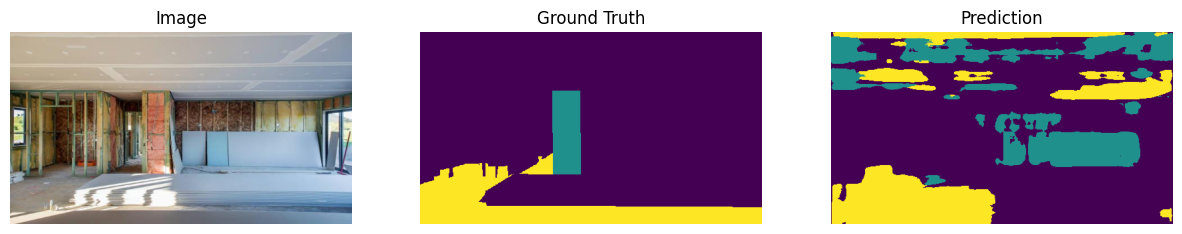

In [51]:
import matplotlib.pyplot as plt

image, mask = test_ds[0]

with torch.no_grad():
    pred = model(
        image.unsqueeze(0).to(DEVICE)
    )

pred = pred.argmax(1)[0].cpu().numpy()

image_vis = image.permute(1,2,0).numpy()

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

image_vis = image_vis * std + mean
image_vis = np.clip(image_vis, 0, 1)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(image_vis)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")
plt.axis("off")

plt.show()

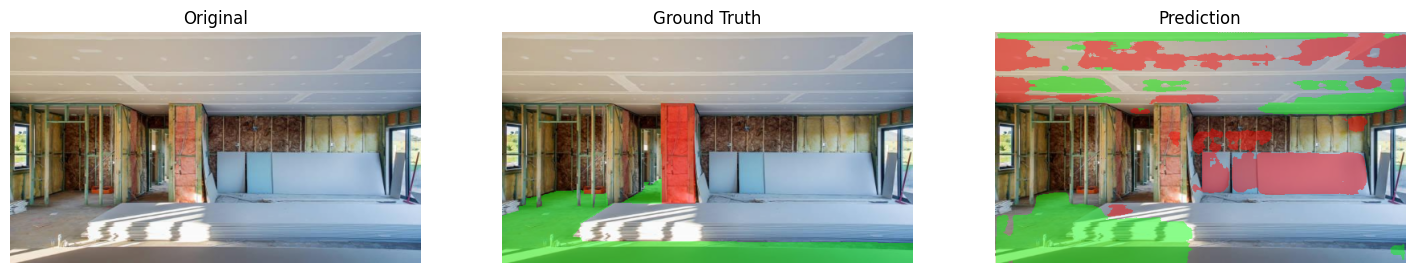

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import torch

image, mask = test_ds[0]

with torch.no_grad():
    pred = model(
        image.unsqueeze(0).to(DEVICE)
    )

pred = pred.argmax(1)[0].cpu().numpy()
mask = mask.numpy()

# Denormalize image
image_vis = image.permute(1,2,0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_vis = image_vis * std + mean
image_vis = np.clip(image_vis, 0, 1)

# Create colored masks
def make_color_mask(mask):
    color_mask = np.zeros(
        (*mask.shape, 4),
        dtype=np.float32
    )

    # Wall = RED
    color_mask[mask == 1] = [1, 0, 0, 0.45]

    # Floor = GREEN
    color_mask[mask == 2] = [0, 1, 0, 0.45]

    return color_mask

gt_color = make_color_mask(mask)
pred_color = make_color_mask(pred)

# Overlay
gt_overlay = image_vis.copy()
pred_overlay = image_vis.copy()

gt_overlay = gt_overlay * (1 - gt_color[:,:,3:]) + gt_color[:,:,:3] * gt_color[:,:,3:]
pred_overlay = pred_overlay * (1 - pred_color[:,:,3:]) + pred_color[:,:,:3] * pred_color[:,:,3:]

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image_vis)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt_overlay)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_overlay)
plt.title("Prediction")
plt.axis("off")

plt.show()

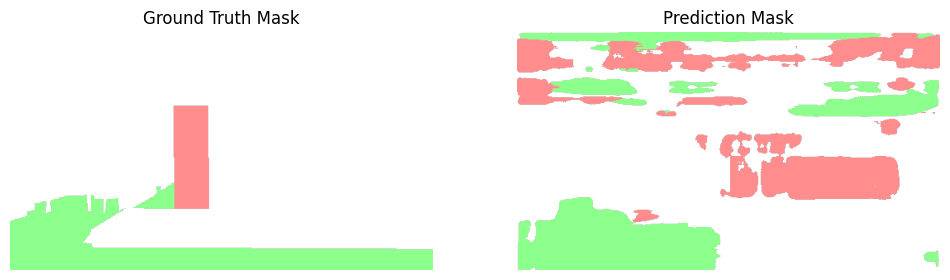

In [53]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gt_color)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred_color)
plt.title("Prediction Mask")
plt.axis("off")

plt.show()

In [63]:
!ls "/content/drive/MyDrive/wall_floor_seg/dataset/test/images"

16_jpg.rf.c0cbdfe1a5fe41ba9ec008e94cd10b74.jpg
26600004490_jpg.rf.c2813e1a586b7285d4ba97b53d7d75f9.jpg
36849015_11_PropertyImage1542741277756_470_1080_jpg.rf.be2973882b5914ca4070b877fd452d92.jpg
3_floor_jpg.rf.8e89f49ec578f5985a734a0880e42594.jpg
48_jpg.rf.ac321fffb5b1236cc0860251436b65da.jpg
58502075_3_PropertyImage1639820590456_470_1080_jpg.rf.c24ab00f25b00c1eef0d2b4c31e12084.jpg
5_jpg.rf.f6cf3c748539acc7e0122dad3c306504.jpg
60037749_5_PropertyImage1653247154347_470_1080_jpg.rf.0cf4357d16de14b0150f326d5f2c11e5.jpg
9-green-living-room-wall-paint-ideas_jpg.rf.6910ef52e3df165a1bff5428e63f87f8.jpg
ADE_train_00000232_jpg.rf.16d7648e54b2a4b41d5deea04d4f8d9e.jpg
ADE_train_00000390_jpg.rf.aaec8006eb25a4f104a8fabd8eab64b8.jpg
ADE_train_00000442_jpg.rf.955f12ea0c7fdeda359feff2454ad45d.jpg
almost-empty-rooms_13_jpeg_jpg.rf.76116231938b91a1a293c89d7b5976b0.jpg
Auction101_jpg.rf.50218d7f982e54f45cc6e53bb698d782.jpg
Auction112_jpg.rf.6bc89948d56d5923befa083ab517ca39.jpg
Auction166_jpg.rf.56e7ebb17

In [54]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

def predict_image(image_path):

    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    original = image.copy()
    h, w = image.shape[:2]

    # Resize for model
    image = cv2.resize(image, (IMG_W, IMG_H))

    # Normalize
    image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = (image - mean) / std
    image = image.unsqueeze(0).to(DEVICE)

    # Prediction
    model.eval()
    with torch.no_grad():
        output = model(image)
        pred = output.argmax(1)[0].cpu().numpy()

    # Back to original image size
    pred = cv2.resize(pred, (w, h), interpolation=cv2.INTER_NEAREST)

    # Transparent colored mask
    overlay = original.copy()

    alpha = 0.45

    # Wall = Red
    wall = pred == 1
    overlay[wall] = (
        original[wall] * (1 - alpha) +
        np.array([255, 0, 0]) * alpha
    ).astype(np.uint8)

    # Floor = Green
    floor = pred == 2
    overlay[floor] = (
        original[floor] * (1 - alpha) +
        np.array([0, 255, 0]) * alpha
    ).astype(np.uint8)

    # Display
    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

    return pred, overlay

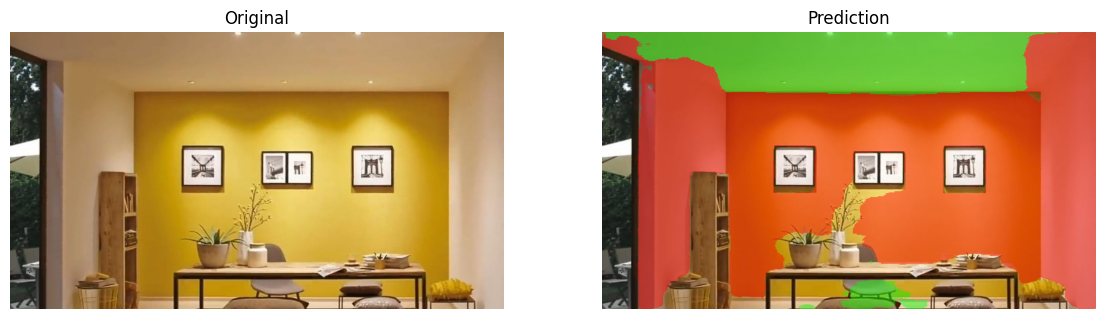

In [65]:
pred, overlay = predict_image(
    "/content/drive/MyDrive/wall_floor_seg/dataset/test/images/image_28_jpg.rf.f06859094d7b6970753c26e401aaeb40.jpg")

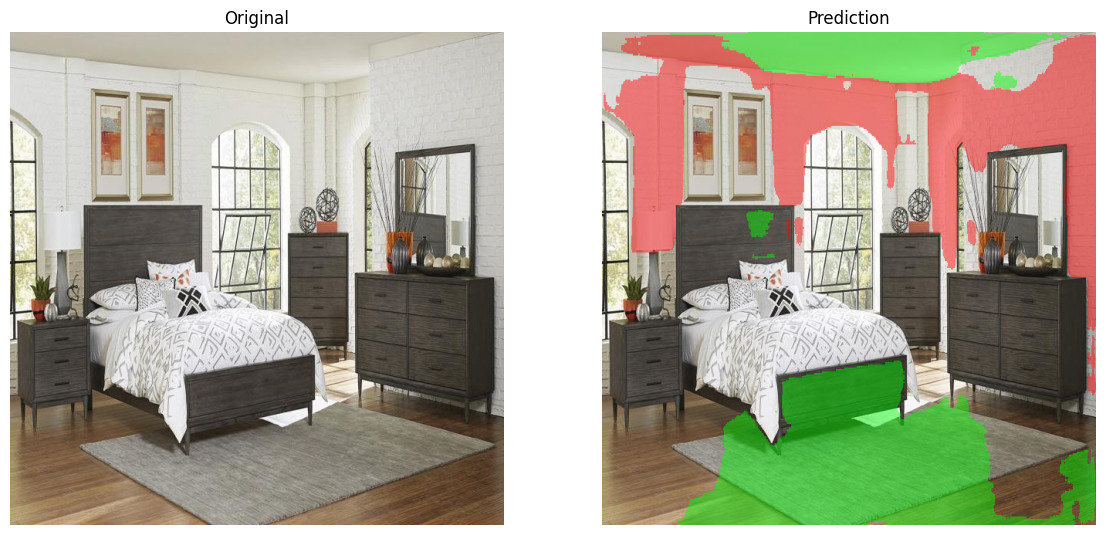

In [66]:
pred, overlay = predict_image(
    "/content/drive/MyDrive/wall_floor_seg/dataset/test/images/bedroom-furniture-ideas-for-small-rooms-1_jpg.rf.a1426b80c7dd5bcce730a3eea321bc1b.jpg")

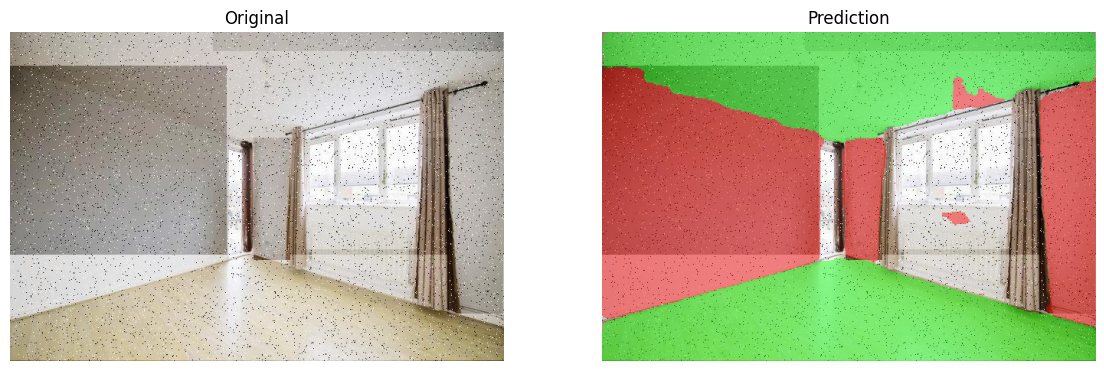

In [67]:
pred, overlay = predict_image(
    "/content/drive/MyDrive/wall_floor_seg/dataset/test/images/Auction353_jpg.rf.4b84e62dee811f7b61421569be4f5505.jpg")